   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

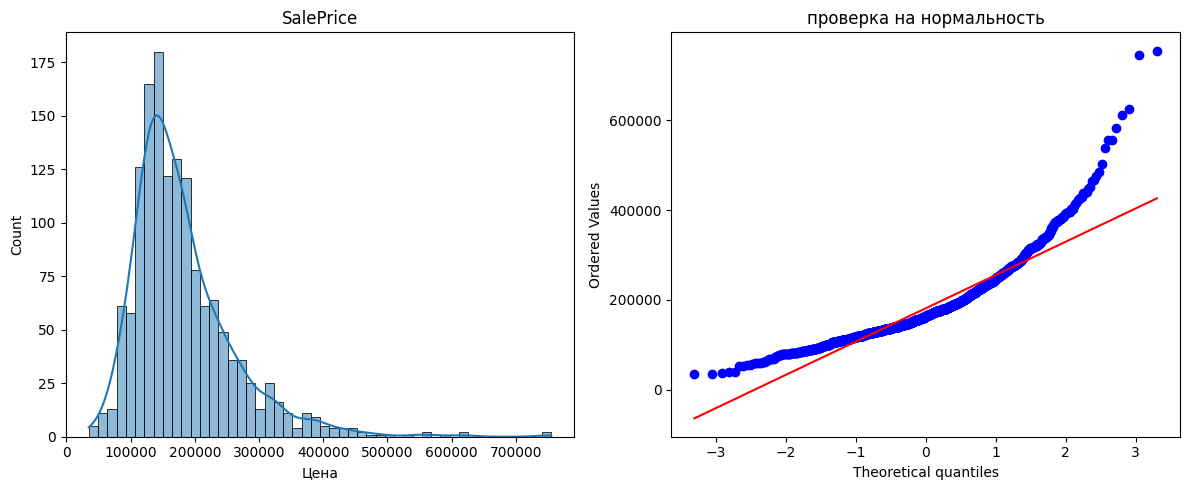

skewness = 1.8828757597682126


/tmp/ipykernel_16/1714540995.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, y='feature', x='importance', palette='viridis')


<Axes: xlabel='importance', ylabel='feature'>

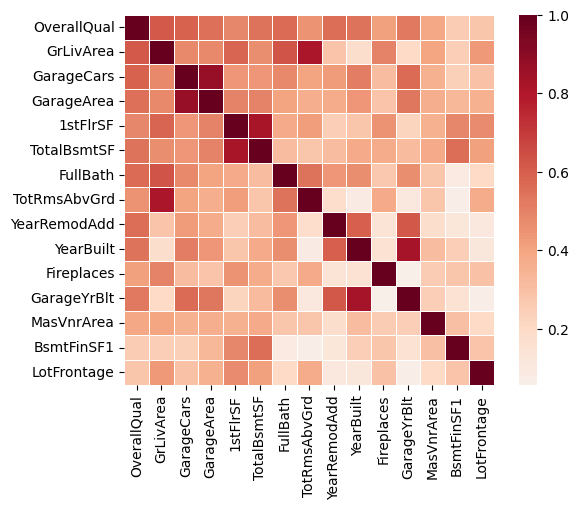

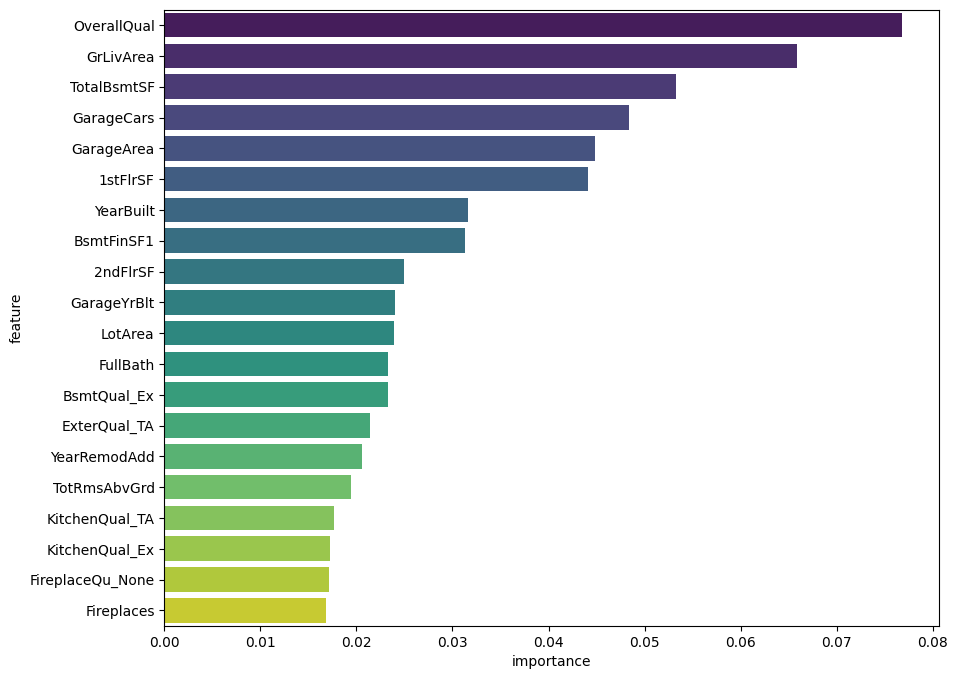

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
train_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
data = pd.read_csv(train_file_path)
print(data.head())

X = data.drop(['Id','SalePrice'],axis=1)
y = data['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
str_cols = X_train.select_dtypes(include=['object']).columns.tolist()

nums = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

strings = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('scaler', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', nums, num_cols),
    ('cat', strings,str_cols)
])

rf = RandomForestRegressor(
    random_state=17,
    n_jobs=-1,
    n_estimators=300
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf)
])

param_grid = {
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}


grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
pred = grid_search.predict(X_test)
val_rmse = mean_squared_error(y_test, pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший MSE на кросс-валидации: {np.sqrt(-grid_search.best_score_):.0f} $")
print(f"RMSE на отложенной валидации: {val_rmse:.0f} $")

real_test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
test_preds = grid_search.predict(real_test)

submission = pd.DataFrame({
    'Id': real_test['Id'],
    'SalePrice': test_preds
})
submission.to_csv('submission.csv', index=False)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, bins=50)
plt.title('SalePrice')
plt.xlabel('Цена')

plt.subplot(1, 2, 2)
stats.probplot(y, dist="norm", plot=plt)
plt.title('проверка на нормальность')

plt.tight_layout()
plt.show()

print(f'skewness = {stats.skew(y,bias=False)}')

numeric_data = X_train.select_dtypes(include=['int64', 'float64']).copy()
numeric_data['SalePrice'] = y_train 
corr_with_target = numeric_data.corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = corr_with_target.drop('SalePrice').head(15).index.tolist()
corr_matrix = numeric_data[top_features].corr()

sns.heatmap(
    corr_matrix,      
    fmt='.2f',    
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5
)

importances = grid_search.best_estimator_.named_steps['model'].feature_importances_

preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
ohe_features = preprocessor.named_transformers_['cat'].named_steps['scaler'].get_feature_names_out(str_cols)
all_features = num_cols + list(ohe_features)

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, y='feature', x='importance', palette='viridis')